# 06 — 着地点参照

足をどこへ置くかを、hip位置・目標速度・速度誤差の3項に分解します。

**前提**: `05_gait_and_contact_schedule.ipynb`

> 読み方: 「直感 → 数式 → 上流コード → 小実験 → 解釈」の順です。
> `実装事実` と書いた箇所は現行 `external/Quadruped-PyMPC` のコード、
> `学習用モデル` は理解のために単純化した再実装です。

In [1]:
# 背景: 各章を同じ作業ディレクトリと依存関係で再実行するには、リポジトリの基準パスと外部実装の場所を最初に固定する必要がある。
# 目的: Quadruped-PyMPCをimport可能にし、acadosとヘッドレスMuJoCoの実行環境を後続セルへ引き渡す。
# ファイルシステム上の基準パスを型安全に扱うためPathを読み込む。
from pathlib import Path
# 環境変数の設定とPythonのモジュール探索パス更新に必要な標準ライブラリを読み込む。
import os, sys

# Notebookを起動した現在位置を絶対パスへ正規化し、教材全体の基準候補とする。
ROOT = Path.cwd().resolve()
# notebook_pympc直下から起動した場合だけ、リポジトリ直下へ基準を1階層戻す。
if ROOT.name == "notebook_pympc":
    # externalディレクトリを参照できるリポジトリ直下へROOTを合わせる。
    ROOT = ROOT.parent
# 上流制御実装が置かれたQuadruped-PyMPCの絶対パスを構成する。
PYMPC_ROOT = ROOT / "external" / "Quadruped-PyMPC"
# 誤った起動位置のまま進まず、依存リポジトリの欠落を具体的なパス付きで検出する。
assert PYMPC_ROOT.exists(), f"Quadruped-PyMPC が見つかりません: {PYMPC_ROOT}"
# 同じパスを重複登録せず、まだimport探索対象でない場合だけ追加する。
if str(PYMPC_ROOT) not in sys.path:
    # ローカルのquadruped_pympcパッケージを通常のimport文で読めるよう探索順の先頭へ置く。
    sys.path.insert(0, str(PYMPC_ROOT))

# acados生成物・共有資源の基準位置を未設定時だけ登録し、利用者の明示設定は上書きしない。
os.environ.setdefault("ACADOS_SOURCE_DIR", str(PYMPC_ROOT / "quadruped_pympc" / "acados"))
# 画面のない環境でもMuJoCoを描画可能にするため、未設定時のOpenGL backendをEGLにする。
os.environ.setdefault("MUJOCO_GL", "egl")
# 実際に採用されたworkspace基準を表示し、相対パス問題を診断できるようにする。
print("workspace :", ROOT)
# import対象となる上流実装の場所を表示し、参照しているコード版を確認可能にする。
print("PyMPC root:", PYMPC_ROOT)

workspace : /home/takuya/work/mpc_dog
PyMPC root: /home/takuya/work/mpc_dog/external/Quadruped-PyMPC


## 実装されるヒューリスティック

heading座標で概略

\[
p_{foot}^{ref}=p_{hip}+p_{width}
  +\frac{T_{stance}}{2}v^{ref}
  +\sqrt{\frac{h}{g}}\left(v-v^{ref}\right)
\]

第3項は歩行中に進む距離の半分、第4項は速度誤差補償です。
誤差補償は各軸 \(\pm0.05\,m\) にclipされます。

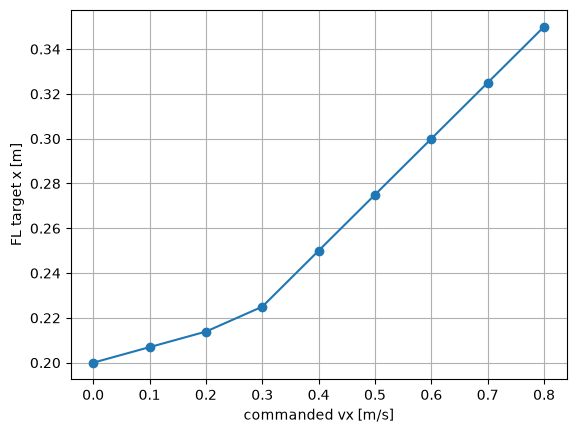

In [2]:
# 背景: 着地点はhip位置だけでなく、stance中の移動量と速度誤差補償で決まり、入力の座標系・単位を揃えないと意図しない方向へずれる。
# 目的: 上流generatorへworld座標の4脚位置と速度指令を与え、指令vx[m/s]に対するFL着地点x[m]の変化を確認する。
# 3次元位置ベクトルと速度掃引配列を作るためNumPyを使う。
import numpy as np
# 指令速度と着地点の関係をグラフ化するためpyplotを使う。
import matplotlib.pyplot as plt
# FL,FR,RL,RRの脚名と各shape (3,)ベクトルを対応づけるためLegsAttrを読む。
from gym_quadruped.utils.quadruped_utils import LegsAttr
# 実装中のRaibert型着地点式を直接評価するため上流generatorを読む。
from quadruped_pympc.helpers.foothold_reference_generator import FootholdReferenceGenerator

# 入力は全てworld座標。脚順はFL, FR, RL, RR。
# 離地時の各足位置[m]を胴体前後・左右に対称なworld座標で定義する。
feet0 = LegsAttr(FL=np.array([.2,.15,0]), FR=np.array([.2,-.15,0]),
                 RL=np.array([-.2,.15,0]), RR=np.array([-.2,-.15,0]))
# 各hip位置[m]を高さ0.3 mのworld座標で定義し、着地点式の基準点にする。
hips = LegsAttr(FL=np.array([.2,.1,.3]), FR=np.array([.2,-.1,.3]),
                RL=np.array([-.2,.1,.3]), RR=np.array([-.2,-.1,.3]))

# T_stance=0.5 sを固定して、上流generatorそのものを作る。
# stance時間[s]・離地位置[m]・hip高さ[m]を固定し、速度指令だけの影響を分離する。
gen = FootholdReferenceGenerator(stance_time=0.5, lift_off_positions=feet0, hip_height=0.32)
# 前進指令vxを0〜0.8 m/sの9点で等間隔に掃引する。
speeds = np.linspace(0, 0.8, 9)
# 各速度に対するFL目標x座標[m]を順序付きで保存する空リストを作る。
x_fl = []
# 指令速度ごとに同じ状態から着地点参照を再計算する。
for vx in speeds:
    # 内部対応式:
    # delta_ref_H = (T_stance/2) * v_ref_H
    # error_H = sqrt(h/g) * (v_H-v_ref_H), 各軸±0.05 mでclip
    # p_foot_ref = p_hip + stance_width_offset + delta_ref_H + error_H
    # base状態を固定し、現在のvxだけを参照速度へ入れて4脚のworld着地点を求める。
    ref = gen.compute_footholds_reference(
        base_position=np.array([0.,0.,.32]),  # base位置[m]をworld原点上、高さ0.32 mに固定する。
        base_ori_euler_xyz=np.zeros(3),  # roll,pitch,yaw[rad]を0にし、headingとworldを一致させる。
        base_xy_lin_vel=np.zeros(2),  # 現在の水平速度[m/s]を0にし、速度誤差項を明確にする。
        ref_base_xy_lin_vel=np.array([vx,0.]),  # heading x方向の目標速度vx[m/s]だけを変える。
        hips_position=hips,  # 4脚のworld hip位置[m]を着地点の幾何基準として渡す。
        com_height_nominal=.32,  # sqrt(h/g)補償に使うnominal COM高さ[m]を渡す。
    )
    # FL参照のx成分[m]だけを抽出し、速度掃引と同じ順で保存する。
    x_fl.append(ref.FL[0])

# v_refを上げるほどT_stance*v_ref/2だけ前方着地点が移ることを確認。
# 横軸vx[m/s]、縦軸FLのworld x目標[m]として点と線で対応を描く。
plt.plot(speeds, x_fl, "o-")
# 速度指令の軸名と単位を付け、独立変数を明示する。
plt.xlabel("commanded vx [m/s]"); plt.ylabel("FL target x [m]")  # 着地点の軸名とworld位置の単位[m]も付ける。
# 傾向とclipによる折れを読み取りやすくするため格子を表示する。
plt.grid(); plt.show()  # 完成した着地点応答図をNotebookへ描画する。

`stance_time` はWBInterface生成時に gait の \(f,eta\) から一度計算されます。
gait周波数を実行中に変える改造では、foothold側のstance時間も同期させないと
数学上の前提が崩れます。これはパラメータ間の結合の例です。

## 章末チェック

出力を眺めるだけでなく、次を自分の言葉で答えてください。

1. この章の入力・出力の shape、単位、座標系は何か。
2. 変更可能な量と、他の章から渡される量は何か。
3. パラメータを2倍にしたとき、どのグラフがどちらへ変化するか。
4. 現行実装の事実と、学習用の近似を区別できるか。